In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy.signal import savgol_filter

from preparation import load_and_prepare_data, handle_duplicate_values, handle_outliers, reindex_daily, handle_missing_values, smooth_remote_data, merge_datasets, slice_by_dates
from config import no_outlier_check

### Data preparation

In [118]:
# North site
insitu_df1 = load_and_prepare_data('../data/processed/in-situ/SDH1_daily-insitu-data.csv')
insitu_df1 = handle_duplicate_values(insitu_df1)
insitu_df1 = reindex_daily(insitu_df1)

# South site
insitu_df2 = load_and_prepare_data('../data/processed/in-situ/SDH2_daily-insitu-data.csv')
insitu_df2 = handle_duplicate_values(insitu_df2)
insitu_df2 = reindex_daily(insitu_df2)

In [119]:
# North site
RED_IRR = insitu_df1['S2411_650-nm-irradiance_Wm-2nm-1']
NIR_IRR = insitu_df1['S2411_810-nm-irradiance_Wm-2nm-1']
RED_RAD = insitu_df1['S2412_650-nm-radiance_Wm-2nm-1sr-1']
NIR_RAD = insitu_df1['S2412_810-nm-radiance_Wm-2nm-1sr-1']

insitu_df1['S2412_650-nm-reflectance'] = (RED_RAD/RED_IRR)
insitu_df1['S2412_810-nm-reflectance'] = (NIR_RAD/NIR_IRR)

# South site
RED_IRR = insitu_df2['S2411_650-nm-irradiance_Wm-2nm-1']
NIR_IRR = insitu_df2['S2411_810-nm-irradiance_Wm-2nm-1']
RED_RAD = insitu_df2['S2412_650-nm-radiance_Wm-2nm-1sr-1']
NIR_RAD = insitu_df2['S2412_810-nm-radiance_Wm-2nm-1sr-1']

insitu_df2['S2412_650-nm-reflectance'] = (RED_RAD/RED_IRR)
insitu_df2['S2412_810-nm-reflectance'] = (NIR_RAD/NIR_IRR)

In [120]:
remote_df = load_and_prepare_data('../data/processed/satellites/SDH1G30P01_sentinel2_bands_indices_TCT_202405-202602.csv')
remote_df = handle_duplicate_values(remote_df)
remote_df = reindex_daily(remote_df)
remote_df = handle_outliers(remote_df, 3.0)
remote_df = handle_missing_values(remote_df, 'time')
remote_df = smooth_remote_data(remote_df, None, 15, 2)

In [121]:
# North site
fused_df1 = merge_datasets(insitu_df1, remote_df)
fused_df1 = slice_by_dates(fused_df1, '2024-05-20', '2026-04-20')
z_df1 = fused_df1.apply(zscore, nan_policy='omit')

# South site
fused_df2 = merge_datasets(insitu_df2, remote_df)
fused_df2 = slice_by_dates(fused_df2, '2024-05-20', '2026-04-20')
z_df2 = fused_df2.apply(zscore, nan_policy='omit')

/opt/miniconda3/envs/dataScience/lib/python3.13/site-packages/pandas/core/apply.py:1081: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)
/opt/miniconda3/envs/dataScience/lib/python3.13/site-packages/pandas/core/apply.py:1081: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)
/opt/miniconda3/envs/dataScience/lib/python3.13/site-packages/pandas/core/apply.py:1081: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)


### Plots

Datos S2-412 historicos (NORTE)

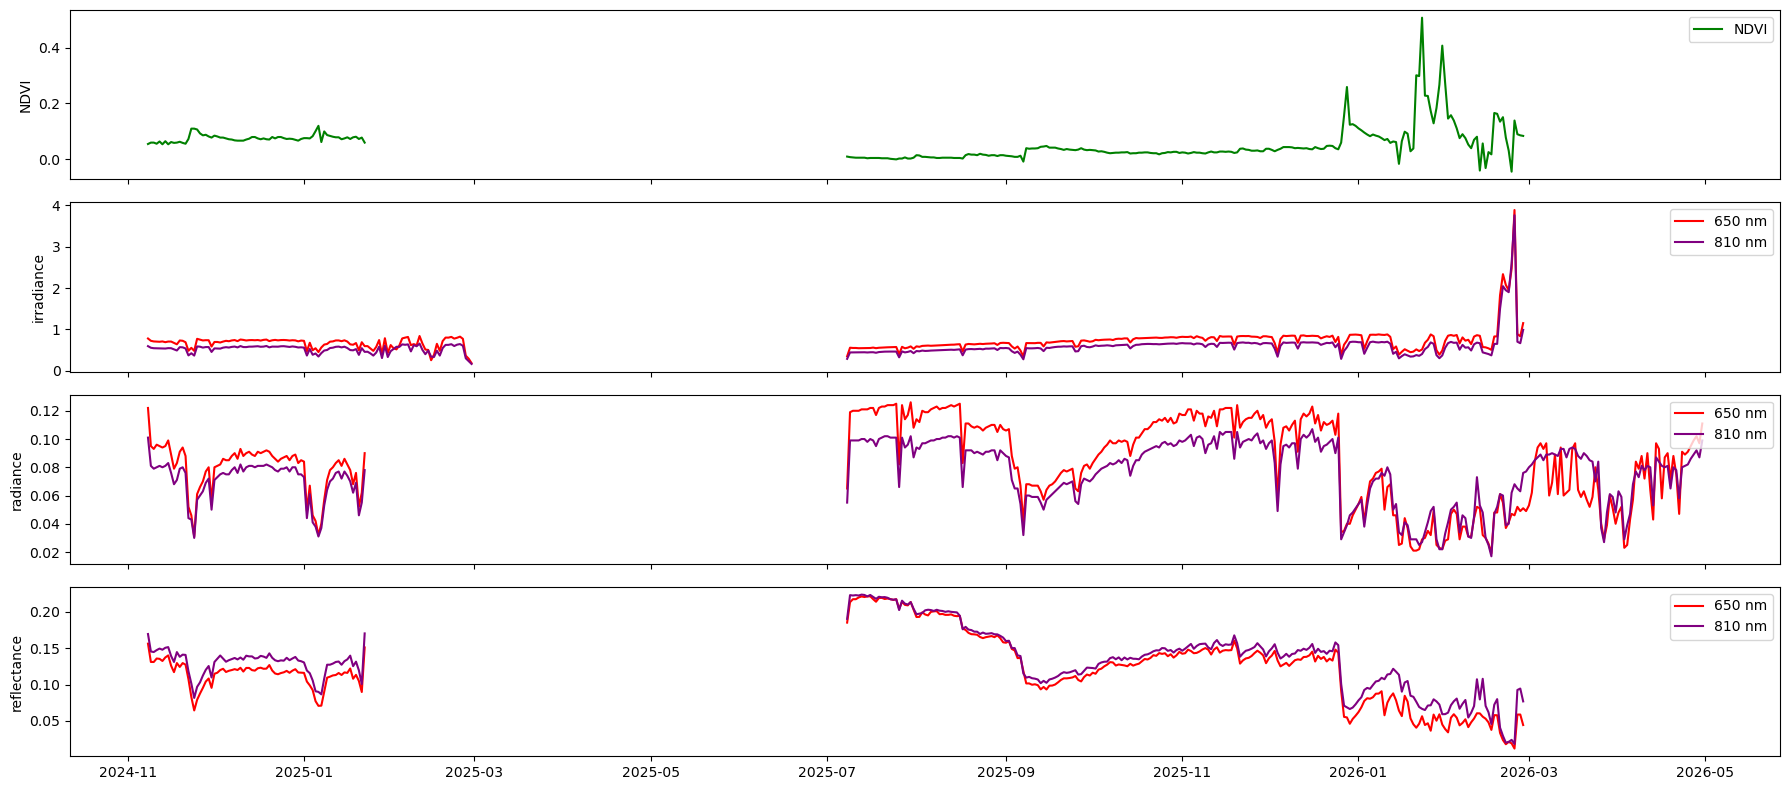

In [122]:
# Figure
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(18, 8), sharex=True)

# Subplot 1
ax1.plot(insitu_df1.index, insitu_df1['S2412_ndvi'], c='green', label='NDVI')
ax1.set_ylabel('NDVI')
ax1.legend(loc='upper right')

# Subplot 2
ax2.plot(insitu_df1.index, insitu_df1['S2411_650-nm-irradiance_Wm-2nm-1'], label='650 nm', c='red')
ax2.plot(insitu_df1.index, insitu_df1['S2411_810-nm-irradiance_Wm-2nm-1'], label='810 nm', c='purple')
ax2.set_ylabel('irradiance')
ax2.legend(loc='upper right')

# Subplot 3
ax3.plot(insitu_df1.index, insitu_df1['S2412_650-nm-radiance_Wm-2nm-1sr-1'], label='650 nm', c='red')
ax3.plot(insitu_df1.index, insitu_df1['S2412_810-nm-radiance_Wm-2nm-1sr-1'], label='810 nm', c='purple')
ax3.set_ylabel('radiance')
ax3.legend(loc='upper right')

# Subplot 4
ax4.plot(insitu_df1.index, insitu_df1['S2412_650-nm-reflectance'], label='650 nm', c='red')
ax4.plot(insitu_df1.index, insitu_df1['S2412_810-nm-reflectance'], label='810 nm', c='purple')
ax4.set_ylabel('reflectance')
ax4.legend(loc='upper right')

plt.tight_layout()
plt.show()

Datos S2-412 historicos (SUR)

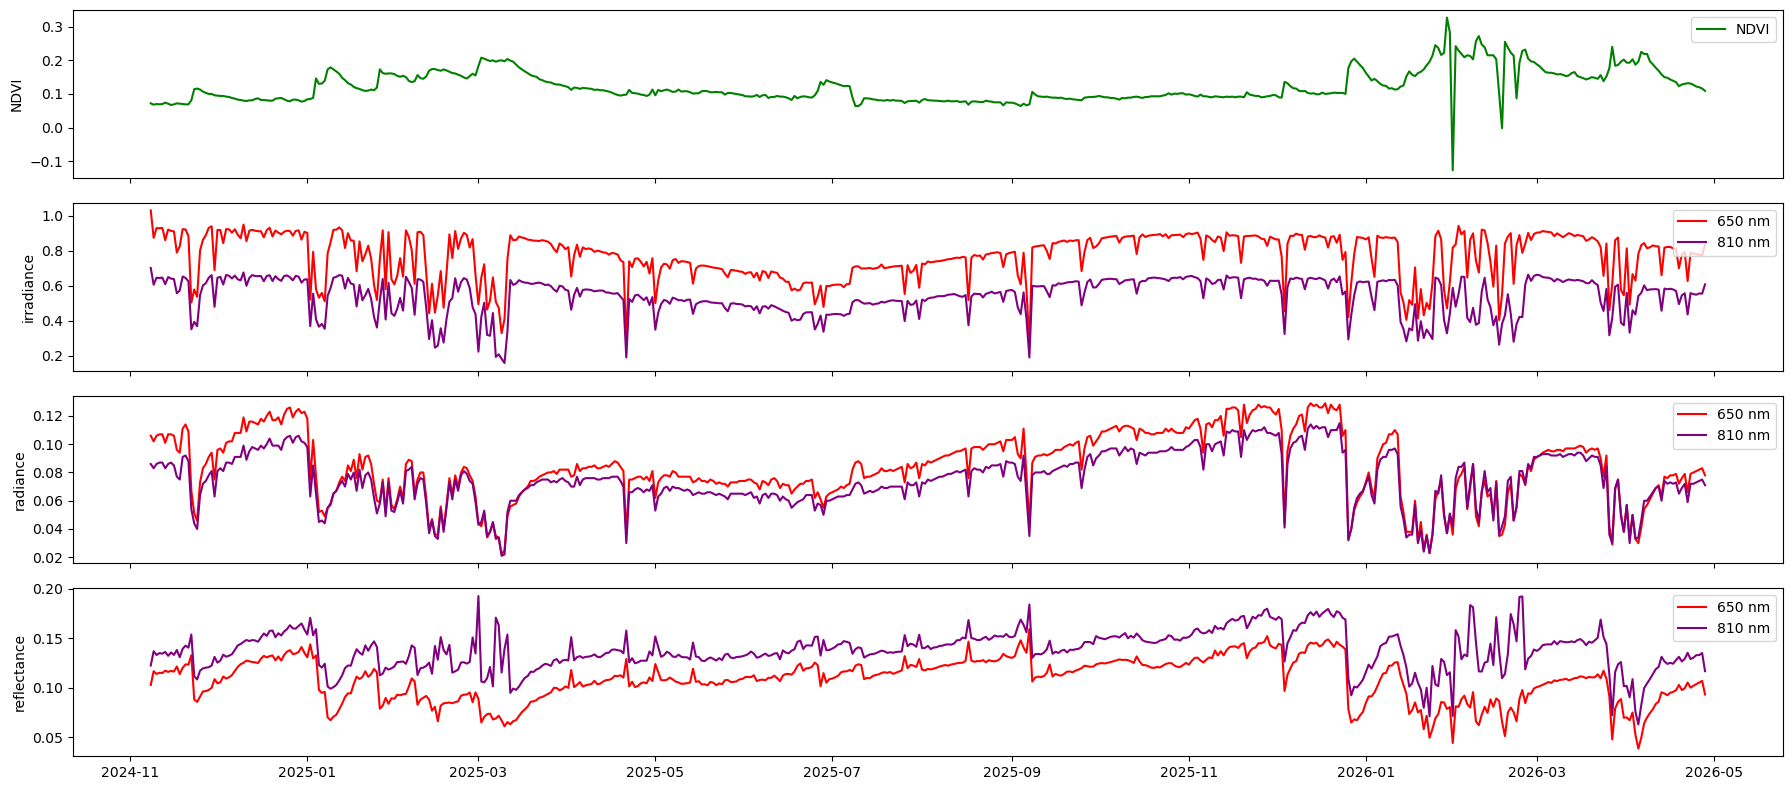

In [123]:
# Figure
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(18, 8), sharex=True)

# Subplot 1
ax1.plot(insitu_df2.index, insitu_df2['S2412_ndvi'], c='green', label='NDVI')
ax1.set_ylabel('NDVI')
ax1.legend(loc='upper right')

# Subplot 2
ax2.plot(insitu_df2.index, insitu_df2['S2411_650-nm-irradiance_Wm-2nm-1'], label='650 nm', c='red')
ax2.plot(insitu_df2.index, insitu_df2['S2411_810-nm-irradiance_Wm-2nm-1'], label='810 nm', c='purple')
ax2.set_ylabel('irradiance')
ax2.legend(loc='upper right')

# Subplot 3
ax3.plot(insitu_df2.index, insitu_df2['S2412_650-nm-radiance_Wm-2nm-1sr-1'], label='650 nm', c='red')
ax3.plot(insitu_df2.index, insitu_df2['S2412_810-nm-radiance_Wm-2nm-1sr-1'], label='810 nm', c='purple')
ax3.set_ylabel('radiance')
ax3.legend(loc='upper right')

# Subplot 4
ax4.plot(insitu_df2.index, insitu_df2['S2412_650-nm-reflectance'], label='650 nm', c='red')
ax4.plot(insitu_df2.index, insitu_df2['S2412_810-nm-reflectance'], label='810 nm', c='purple')
ax4.set_ylabel('reflectance')
ax4.legend(loc='upper right')

plt.tight_layout()
plt.show()

Compararación datos insitu vs remotos (NORTE)

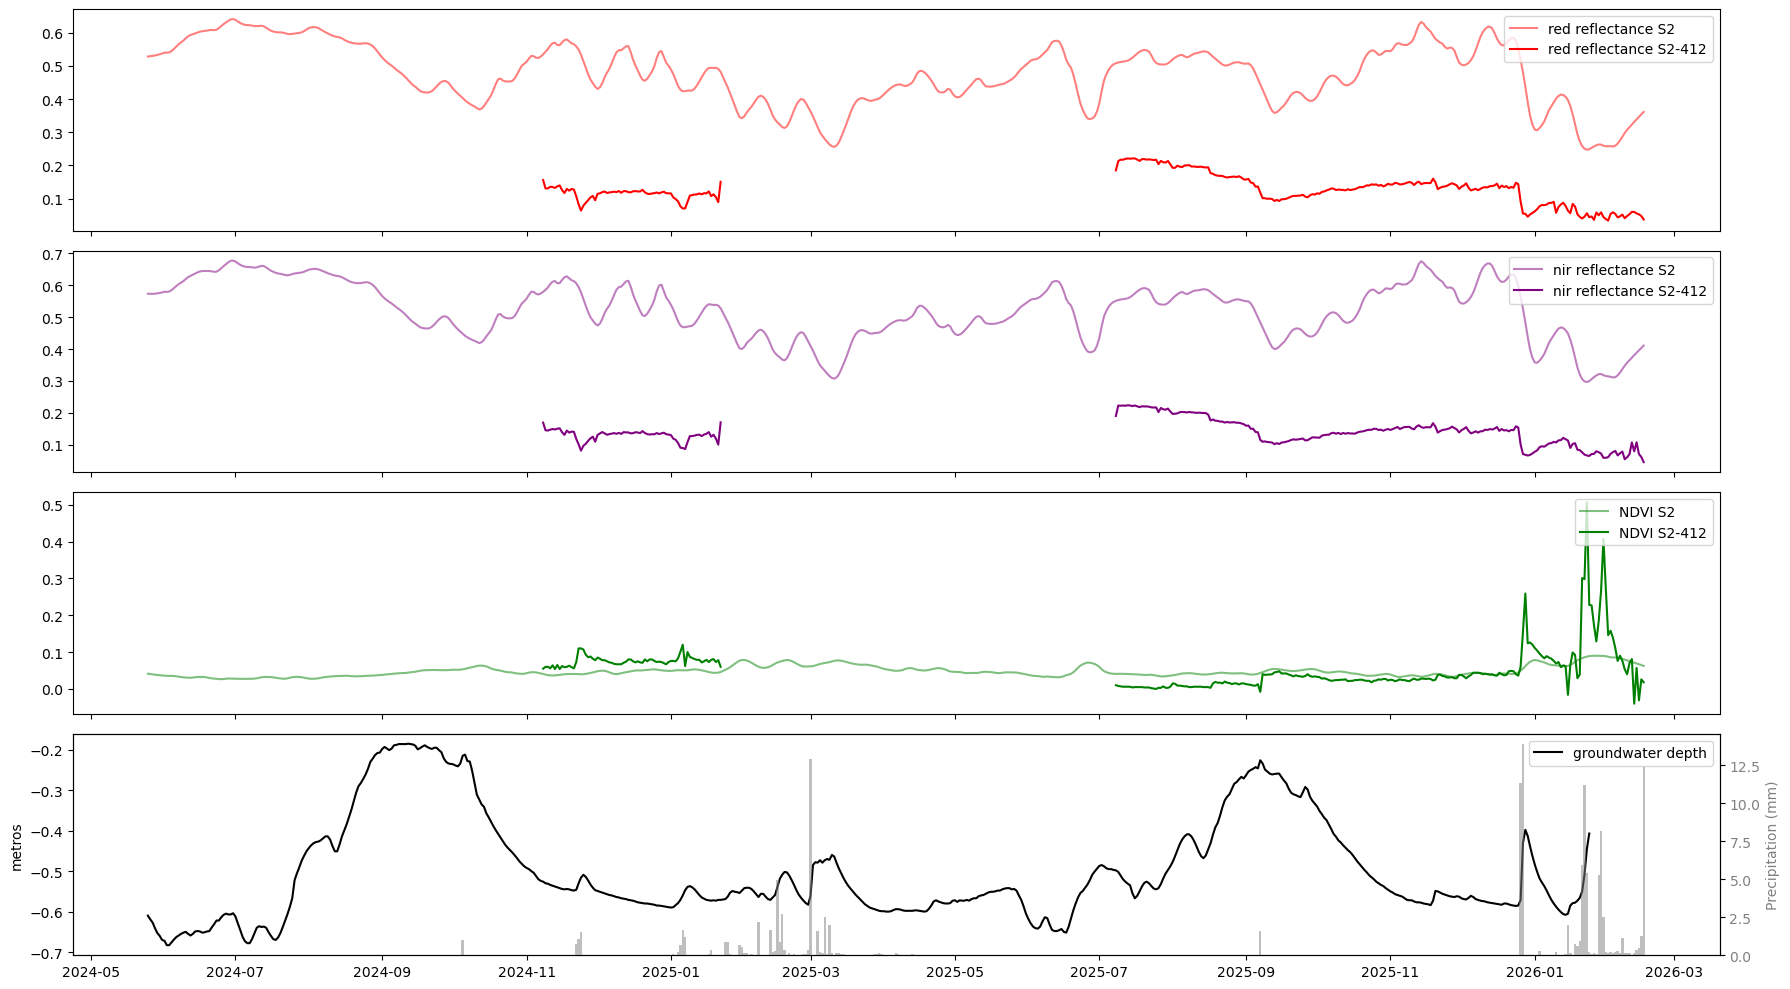

In [124]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(18, 10), sharex=True)

# Subplot 1
ax1.plot(fused_df1.index, fused_df1['s2_B4'], label='red reflectance S2', c='red', alpha=0.5)
ax1.plot(fused_df1.index, fused_df1['S2412_650-nm-reflectance'], label='red reflectance S2-412', c='red')
ax1.legend(loc='upper right')

# Subplot 2
ax2.plot(fused_df1.index, fused_df1['s2_B8'], label='nir reflectance S2', c='purple', alpha=0.5)
ax2.plot(fused_df1.index, fused_df1['S2412_810-nm-reflectance'], label='nir reflectance S2-412', c='purple')
ax2.legend(loc='upper right')

# Subplot 3
ax3.plot(fused_df1.index, fused_df1['s2_ndvi'], label='NDVI S2', c='green', alpha=0.5)
ax3.plot(fused_df1.index, fused_df1['S2412_ndvi'], c='green', label='NDVI S2-412')
ax3.legend(loc='upper right')

#Subplot 4
ax4.plot(fused_df1.index, fused_df1['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black', alpha=1)
ax4.set_ylabel('metros')
ax4.legend(loc='upper right')
# Configure secondary y axis
ax5 = ax4.twinx()
ax5.bar(fused_df1.index, fused_df1['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax5.set_ylabel('Precipitation (mm)', color='gray')
ax5.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

Compararación datos insitu vs remotos estandarizados (NORTE)

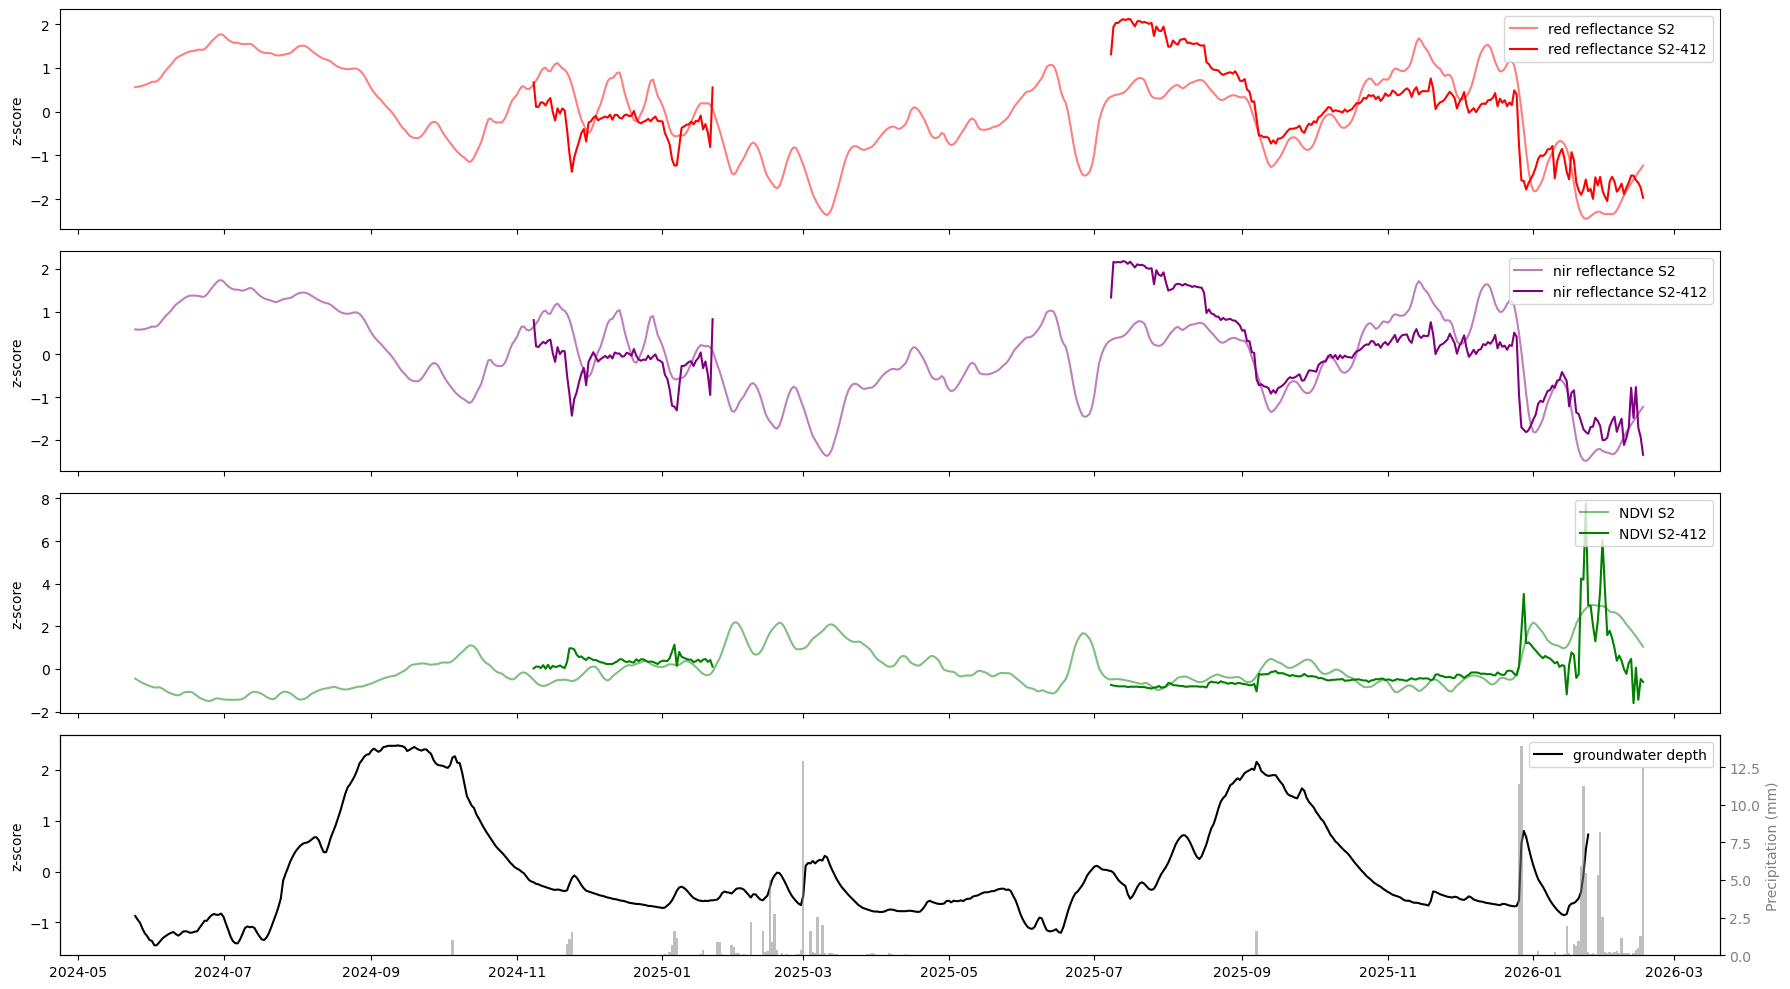

In [125]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(18, 10), sharex=True)

# Subplot 1
ax1.plot(z_df1.index, z_df1['s2_B4'], label='red reflectance S2', c='red', alpha=0.5)
ax1.plot(z_df1.index, z_df1['S2412_650-nm-reflectance'], label='red reflectance S2-412', c='red')
ax1.set_ylabel('z-score')
ax1.legend(loc='upper right')

# Subplot 2
ax2.plot(z_df1.index, z_df1['s2_B8'], label='nir reflectance S2', c='purple', alpha=0.5)
ax2.plot(z_df1.index, z_df1['S2412_810-nm-reflectance'], label='nir reflectance S2-412', c='purple')
ax2.set_ylabel('z-score')
ax2.legend(loc='upper right')

# Subplot 3
ax3.plot(z_df1.index, z_df1['s2_ndvi'], label='NDVI S2', c='green', alpha=0.5)
ax3.plot(z_df1.index, z_df1['S2412_ndvi'], c='green', label='NDVI S2-412')
ax3.set_ylabel('z-score')
ax3.legend(loc='upper right')

#Subplot 4
ax4.plot(z_df1.index, z_df1['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black', alpha=1)
ax4.set_ylabel('z-score')
ax4.legend(loc='upper right')
# Configure secondary y axis
ax5 = ax4.twinx()
ax5.bar(fused_df1.index, fused_df1['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax5.set_ylabel('Precipitation (mm)', color='gray')
ax5.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()


NDVI estandarizado vs niveles freaticos y precipitaciones

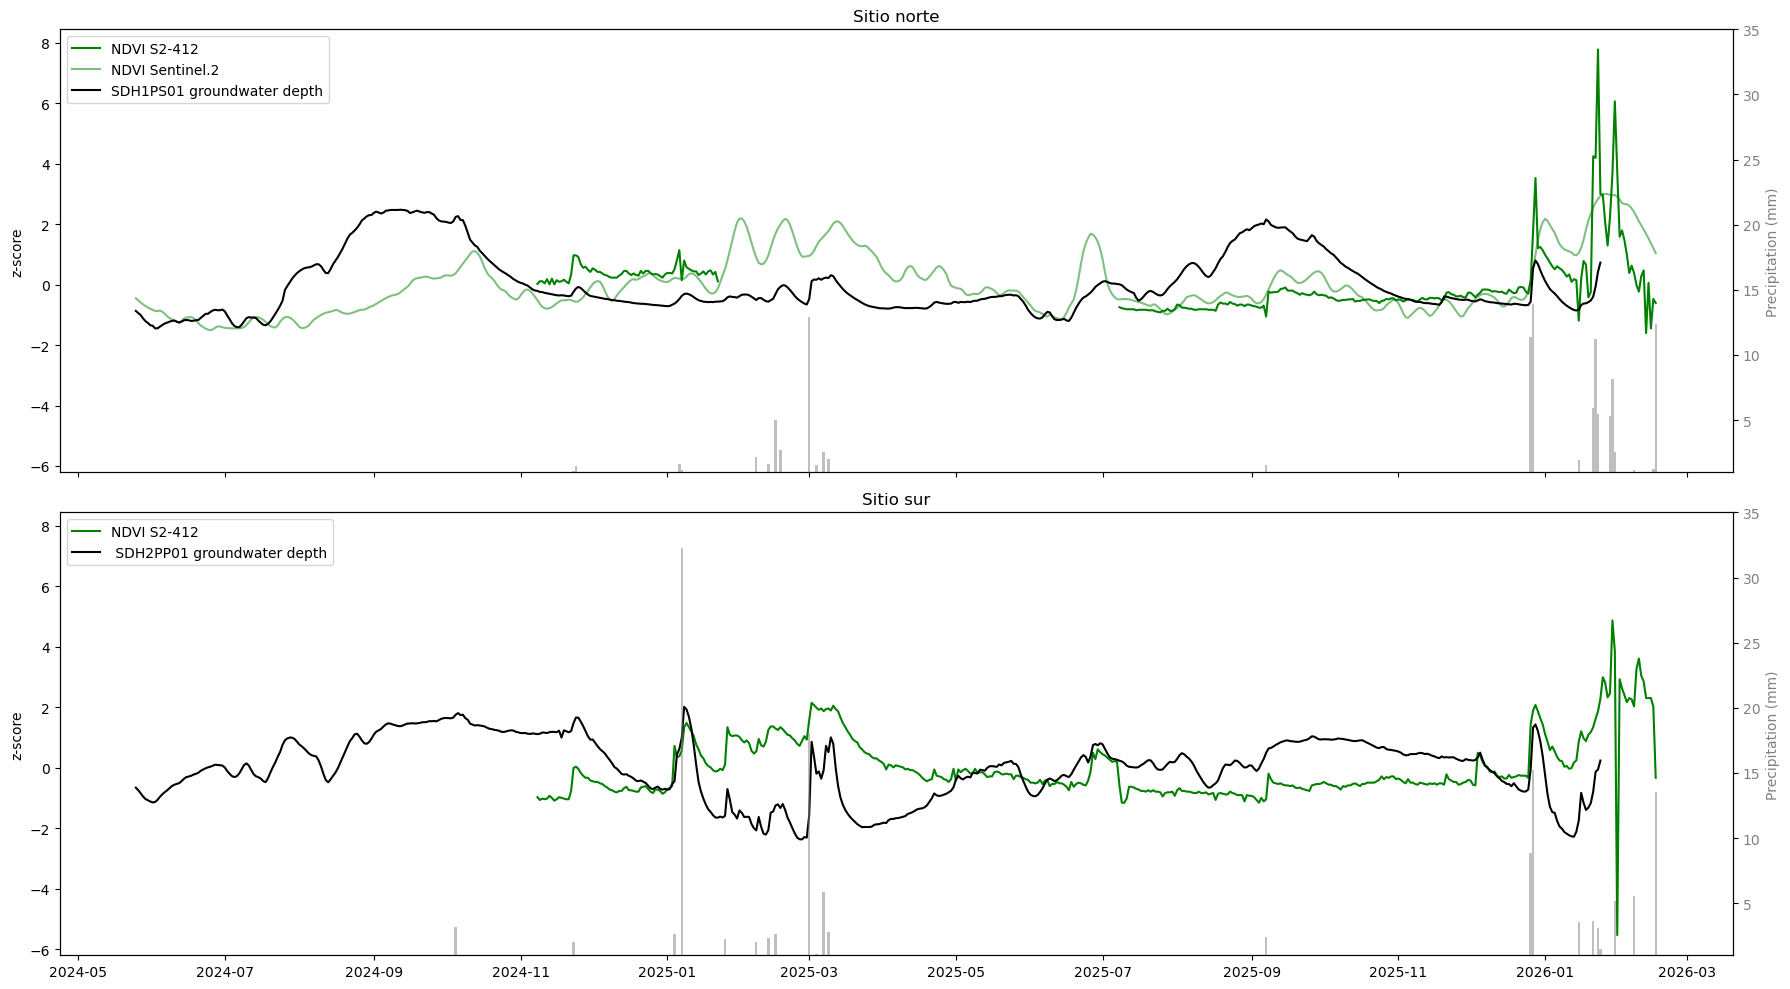

In [127]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True, sharey=True)

# Subplot 1
ax1.plot(z_df1.index, z_df1['S2412_ndvi'], c='green', label='NDVI S2-412')
ax1.plot(z_df1.index, z_df1['s2_ndvi'], label='NDVI Sentinel.2', c='green', alpha=0.5)
ax1.plot(z_df1.index, z_df1['SDH1PS01_gw-depth_m'], label='SDH1PS01 groundwater depth', c='black', alpha=1)
ax1.set_ylabel('z-score')
ax1.legend(loc='upper left')
ax1.set_title('Sitio norte')
# Configure secondary y axis
ax3 = ax1.twinx()
ax3.set_ylim(35)
ax3.invert_yaxis()
ax3.bar(fused_df1.index, fused_df1['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax3.set_ylabel('Precipitation (mm)', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

# Subplot 2
ax2.plot(z_df2.index, z_df2['S2412_ndvi'], c='green', label='NDVI S2-412')
ax2.plot(z_df2.index, z_df2['SDH2PP01_gw-depth_m'], label=' SDH2PP01 groundwater depth', c='black', alpha=1)
ax2.set_ylabel('z-score')
ax2.legend(loc='upper left')
ax2.set_title('Sitio sur')
# Configure secondary y axis
ax4 = ax2.twinx()
ax4.set_ylim(35)
ax4.invert_yaxis()
ax4.bar(fused_df2.index, fused_df2['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax4.set_ylabel('Precipitation (mm)', color='gray')
ax4.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

Conclusiones
El NDVI insitu parece responder principalmente a las precipitaciones, no a cambios en el nivel freático.
Las precipitaciones son de mayor magnitud en el sitio sur.
La magnitud del pulso de primavera es menor en el sitio sur.
En 2025-07 se ve un pulso de aumento del NDVI (satelital e insitu) no asociado a precipitaciones (nieve?)
